# Superstore Sales Analysis
**Analysis of sales and profitability from 2015 to 2018.**

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('superstore.csv')

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
2,3,CA-2017-138688,6/12/2017,6/16/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714
3,4,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
4,5,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10800 entries, 0 to 10799
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         10800 non-null  str    
 1   Order ID       10800 non-null  str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9983 non-null   float64
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       99

## Data Cleaning

In [5]:
df.isnull().sum()

Row ID             0
Order ID           0
Order Date       806
Ship Date        806
Ship Mode        806
Customer ID      806
Customer Name    806
Segment          806
Country          806
City             806
State            806
Postal Code      817
Region           806
Product ID       806
Category         806
Sub-Category     806
Product Name     806
Sales            806
Quantity         806
Discount         806
Profit           806
dtype: int64

In [6]:
df = df.dropna(subset=['Sales'])
df = df.drop_duplicates()

## Revenue and Profit Trends

In [7]:
print(df['Order Date'].dtype)

str


In [8]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [9]:
print(df['Order Date'].dtype)

datetime64[us]


Order Date
2015    484247.4981
2016    470532.5090
2017    609205.5980
2018    733215.2552
Name: Sales, dtype: float64


<Axes: xlabel='Order Date'>

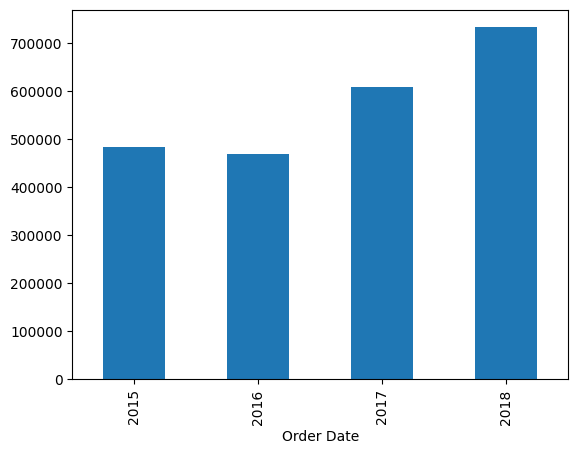

In [10]:
sales_by_year = df.groupby(df['Order Date'].dt.year)['Sales'].sum()

print(sales_by_year)

sales_by_year.plot(kind='bar')

Order Date
2015    49543.9741
2016    61618.6037
2017    81795.1743
2018    93439.2696
Name: Profit, dtype: float64


<Axes: xlabel='Order Date'>

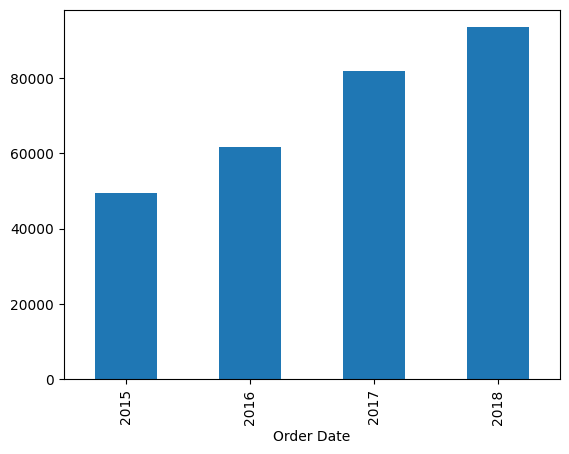

In [11]:
profit_by_year = df.groupby(df['Order Date'].dt.year)['Profit'].sum()

print(profit_by_year)

profit_by_year.plot(kind='bar')

Order Date
2015    1993
2016    2102
2017    2587
2018    3312
Name: Order ID, dtype: int64


<Axes: xlabel='Order Date'>

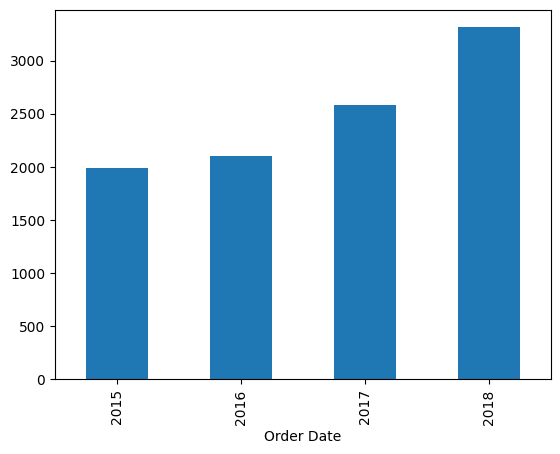

In [12]:
orders_by_year = df.groupby(df['Order Date'].dt.year)['Order ID'].count()

print(orders_by_year)

orders_by_year.plot(kind='bar')

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64


<Axes: xlabel='Category'>

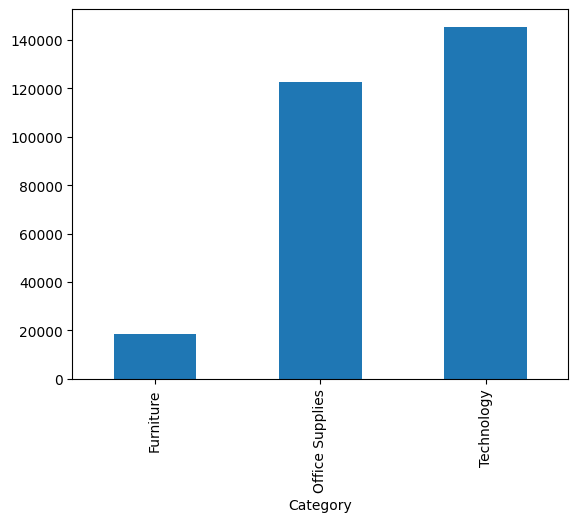

In [13]:
category_profit = df.groupby('Category')['Profit'].sum()

print(category_profit)

category_profit.plot(kind='bar')

Sub-Category
Tables        -17725.4811
Bookcases      -3472.5560
Supplies       -1189.0995
Fasteners        949.5182
Machines        3384.7569
Labels          5546.2540
Art             6527.7870
Envelopes       6964.1767
Furnishings    13059.1436
Appliances     18138.0054
Storage        21278.8264
Chairs         26590.1663
Binders        30221.7633
Paper          34053.5693
Accessories    41936.6357
Phones         44515.7306
Copiers        55617.8249
Name: Profit, dtype: float64


<Axes: ylabel='Sub-Category'>

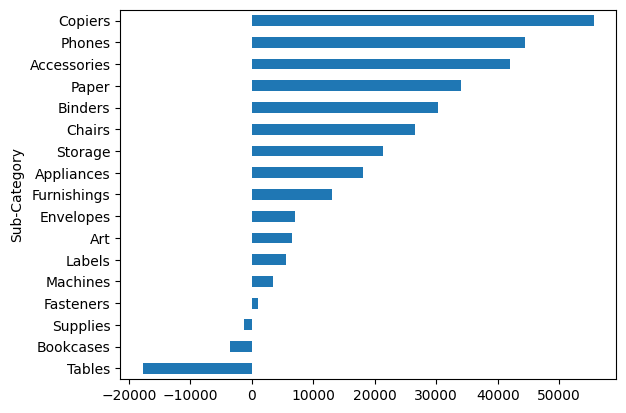

In [14]:
subcategory_profit = (
    df.groupby('Sub-Category')['Profit']
      .sum()
      .sort_values()
)

print(subcategory_profit)

subcategory_profit.plot(kind='barh')

<Axes: title={'center': 'Monthly Profit Trend'}, xlabel='Order Date'>

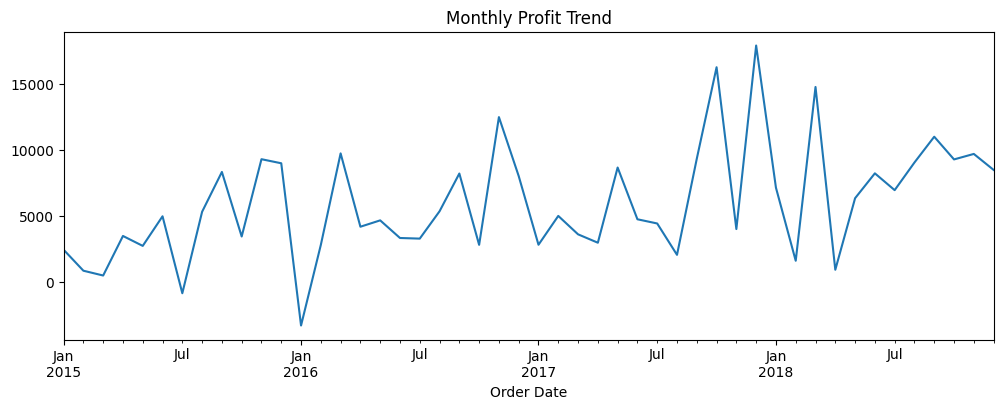

In [21]:
monthly_profit = df.groupby(df['Order Date'].dt.to_period('M'))['Profit'].sum()
monthly_profit.plot(figsize=(12,4), title='Monthly Profit Trend')

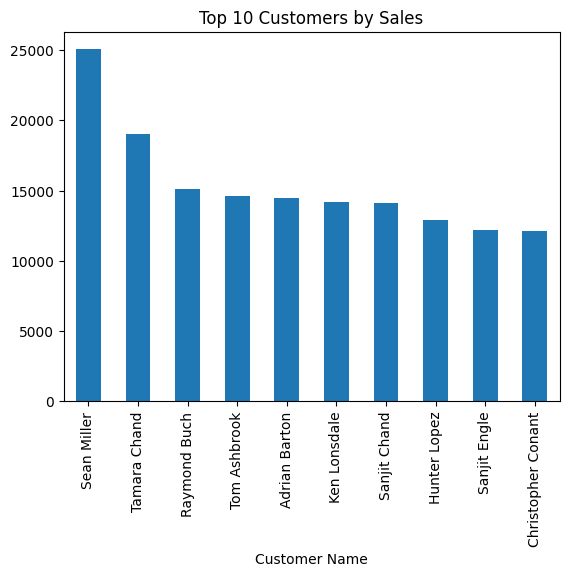

In [22]:
top10_customers = customer_sales.head(10)
top10_customers.plot(kind='bar', title='Top 10 Customers by Sales');

In [19]:
customer_sales = (
    df.groupby('Customer Name')['Sales']
      .sum()
      .sort_values(ascending=False)
)

customer_cum_pct = customer_sales.cumsum() / customer_sales.sum()

top_customers = (customer_cum_pct <= 0.8).sum()

print(top_customers)
print(len(customer_sales))

395
793


### 📊 Pareto Analysis Results
* **Top Customers:** 185 out of 793 unique customers generate 80% of the total revenue.
* **Top Products:** 395 out of 1,850 unique products generate 80% of the total revenue.

In [20]:
df['Order Date'].min()

Timestamp('2015-01-03 00:00:00')